In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns

In [28]:
df=pd.read_csv(r"C:\DESKTOP_FILES\project\data\survey_results_public.csv")
df.head() 

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [29]:
df.shape


(65437, 114)

In [30]:
for col in df.columns:
    print(col)

ResponseId
MainBranch
Age
Employment
RemoteWork
Check
CodingActivities
EdLevel
LearnCode
LearnCodeOnline
TechDoc
YearsCode
YearsCodePro
DevType
OrgSize
PurchaseInfluence
BuyNewTool
BuildvsBuy
TechEndorse
Country
Currency
CompTotal
LanguageHaveWorkedWith
LanguageWantToWorkWith
LanguageAdmired
DatabaseHaveWorkedWith
DatabaseWantToWorkWith
DatabaseAdmired
PlatformHaveWorkedWith
PlatformWantToWorkWith
PlatformAdmired
WebframeHaveWorkedWith
WebframeWantToWorkWith
WebframeAdmired
EmbeddedHaveWorkedWith
EmbeddedWantToWorkWith
EmbeddedAdmired
MiscTechHaveWorkedWith
MiscTechWantToWorkWith
MiscTechAdmired
ToolsTechHaveWorkedWith
ToolsTechWantToWorkWith
ToolsTechAdmired
NEWCollabToolsHaveWorkedWith
NEWCollabToolsWantToWorkWith
NEWCollabToolsAdmired
OpSysPersonal use
OpSysProfessional use
OfficeStackAsyncHaveWorkedWith
OfficeStackAsyncWantToWorkWith
OfficeStackAsyncAdmired
OfficeStackSyncHaveWorkedWith
OfficeStackSyncWantToWorkWith
OfficeStackSyncAdmired
AISearchDevHaveWorkedWith
AISearchDevWantTo

In [31]:
df = df.rename({"ConvertedCompYearly": "Salary"}, axis=1)
df = df[["Country", "EdLevel", "YearsCodePro", "WorkExp", "DevType", "Salary"]]
df.head()

,Country,EdLevel,YearsCodePro,WorkExp,DevType,Salary
0,United States of America,Primary/elementary school,NaN,NaN,NaN,NaN
1,United Kingdom of Great Britain and Northern I...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",17,17.0,"Developer, full-stack",NaN
2,United Kingdom of Great Britain and Northern I...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",27,NaN,Developer Experience,NaN
3,Canada,Some college/university study without earning ...,NaN,NaN,"Developer, full-stack",NaN
4,Norway,"Secondary school (e.g. American high school, G...",NaN,NaN,"Developer, full-stack",NaN


In [32]:
df.shape

(65437, 6)

In [33]:
df=df.dropna(subset="Salary")
df.shape

(23435, 6)

In [34]:
df.isnull().sum()

Country            0
EdLevel            0
YearsCodePro      90
WorkExp         7291
DevType           32
Salary             0
dtype: int64

In [35]:
#welp 7.2k missing values in WorkExp gotta drop em
df=df.drop("WorkExp",axis=1)
df.isnull().sum()


Country          0
EdLevel          0
YearsCodePro    90
DevType         32
Salary           0
dtype: int64

In [36]:
df.head()
df.shape

(23435, 5)

In [37]:
df=df.dropna()
df.isnull().sum()

Country         0
EdLevel         0
YearsCodePro    0
DevType         0
Salary          0
dtype: int64

In [38]:
df.shape

(23321, 5)

In [39]:
df.dtypes

Country          object
EdLevel          object
YearsCodePro     object
DevType          object
Salary          float64
dtype: object

In [40]:
df["YearsCodePro"].unique()

array(['1', '6', '17', '7', '18', '25', '30', '20', '50', '27', '16', '4',
       '15', '11', '23', '10', '9', '8', '24', '12', '26', '40',
       'Less than 1 year', '14', '22', '5', '28', '3', '44', '42', '13',
       '19', '2', '35', '31', '41', '36', '38', '32', '34', '21',
       'More than 50 years', '29', '45', '43', '37', '33', '48', '39',
       '46', '49', '47'], dtype=object)

In [41]:
def fit(x):
    if x=="Less than 1 year":
        return 0.5
    elif x=="More than 50 years":
        return 50
    else:
        return float(x)
df["YearsCodePro"]=df["YearsCodePro"].apply(fit)
df.dtypes

Country          object
EdLevel          object
YearsCodePro    float64
DevType          object
Salary          float64
dtype: object

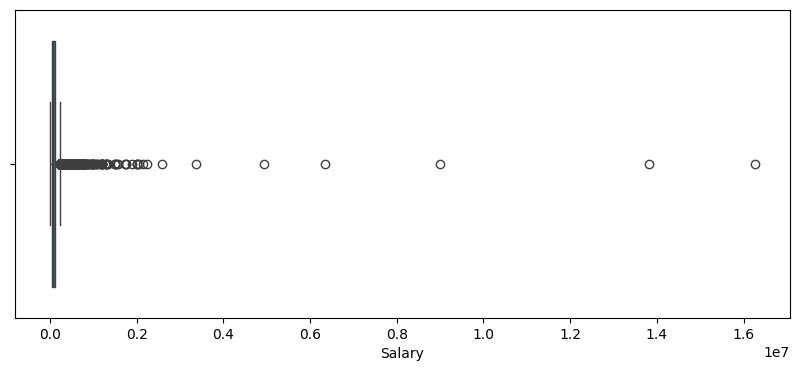

Q1: $32921.0
Q3: $108000.0
 Lower Bound: $-79697.5
 Upper Bound: $220618.5


In [42]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["Salary"])
plt.show()
Q1 = df["Salary"].quantile(0.25) #
Q3 = df["Salary"].quantile(0.75) 
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Q1: ${Q1}")
print(f"Q3: ${Q3}")
print(f" Lower Bound: ${lower_bound}")
print(f" Upper Bound: ${upper_bound}")

In [43]:
df = df[df["Salary"] <= 220618.5]
df.shape

(22349, 5)

In [44]:
counts=df["Country"].value_counts()
counts


Country
United States of America                                3972
Germany                                                 2017
Ukraine                                                 1454
United Kingdom of Great Britain and Northern Ireland    1316
India                                                   1022
                                                        ... 
Libyan Arab Jamahiriya                                     1
Sudan                                                      1
Central African Republic                                   1
Oman                                                       1
Haiti                                                      1
Name: count, Length: 165, dtype: int64

In [45]:
valid=counts[counts>=100].index
valid

Index(['United States of America', 'Germany', 'Ukraine',
       'United Kingdom of Great Britain and Northern Ireland', 'India',
       'France', 'Canada', 'Brazil', 'Poland', 'Netherlands', 'Spain', 'Italy',
       'Australia', 'Sweden', 'Switzerland', 'Austria', 'Czech Republic',
       'Russian Federation', 'Norway', 'Israel', 'Denmark', 'Belgium',
       'Turkey', 'Portugal', 'Greece', 'Finland', 'Mexico', 'South Africa',
       'Romania', 'New Zealand', 'Hungary', 'Argentina', 'Pakistan', 'Ireland',
       'Bangladesh', 'Bulgaria', 'Japan', 'Iran, Islamic Republic of...',
       'Indonesia'],
      dtype='object', name='Country')

In [46]:
def group_country(country):
    if country in valid:
        return country
    else:
        return "Other"

# 3. Apply the function to the column
df["Country"] = df["Country"].apply(group_country)
print(df["Country"].value_counts())

Country
United States of America                                3972
Other                                                   2462
Germany                                                 2017
Ukraine                                                 1454
United Kingdom of Great Britain and Northern Ireland    1316
India                                                   1022
France                                                   904
Canada                                                   833
Brazil                                                   671
Poland                                                   582
Netherlands                                              549
Spain                                                    548
Italy                                                    536
Australia                                                498
Sweden                                                   451
Switzerland                                              368
Austria         

In [47]:
df["EdLevel"].unique()

array(['Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)',
       'Professional degree (JD, MD, Ph.D, Ed.D, etc.)',
       'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)',
       'Some college/university study without earning a degree',
       'Bachelor’s degree (B.A., B.S., B.Eng., etc.)',
       'Associate degree (A.A., A.S., etc.)', 'Primary/elementary school',
       'Something else'], dtype=object)

In [48]:
from sklearn.preprocessing import LabelEncoder
def education(x):
    if 'Bachelor’s degree' in x:
        return 'Bachelor’s degree'
    if 'Master’s degree' in x:
        return 'Master’s degree'
    if 'Professional degree' in x:
        return 'Post grad'
    return 'Less than a Bachelors'
df['EdLevel'] = df['EdLevel'].apply(education)
ed_mapping = {
    "Less than a Bachelors": 0,
    "Bachelor’s degree": 1,
    "Master’s degree": 2,
    "Post grad": 3
}
df["EdLevel"] = df["EdLevel"].map(ed_mapping)
le_country = LabelEncoder()
df["Country"] = le_country.fit_transform(df["Country"])
le_dev = LabelEncoder()
df["DevType"] = le_dev.fit_transform(df["DevType"])
print(df.head())
print("-" * 20)
print(df.dtypes)

     Country  EdLevel  YearsCodePro  DevType    Salary
72        27        0           1.0        5    7322.0
374        2        3           6.0        0   30074.0
379       36        2           6.0        5   91295.0
385       11        2          17.0       13   53703.0
389       39        0           7.0       32  110000.0
--------------------
Country           int32
EdLevel           int64
YearsCodePro    float64
DevType           int32
Salary          float64
dtype: object


In [49]:
df.shape

(22349, 5)

In [50]:
x=df.drop("Salary", axis=1)
y=df["Salary"]
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

R2_Score for : LinearRegression is 0.22557306134528854
R2_Score for : Lasso is 0.22557299233761408
R2_Score for : LassoCV is 0.2255704704926098
R2_Score for : Ridge is 0.22557264998584503
R2_Score for : RidgeCV is 0.2255688751012589
R2_Score for : RandomForest is 0.5119589867024867


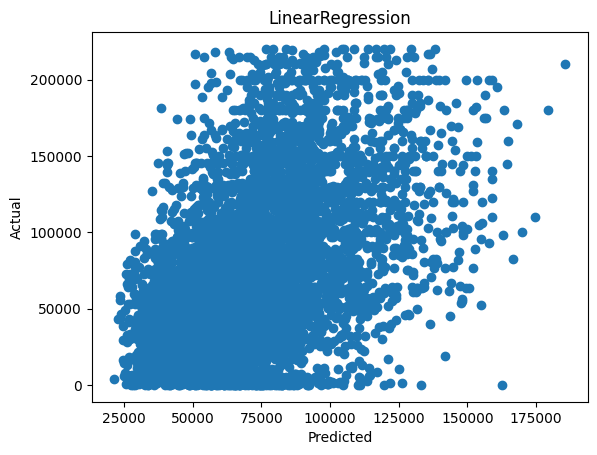

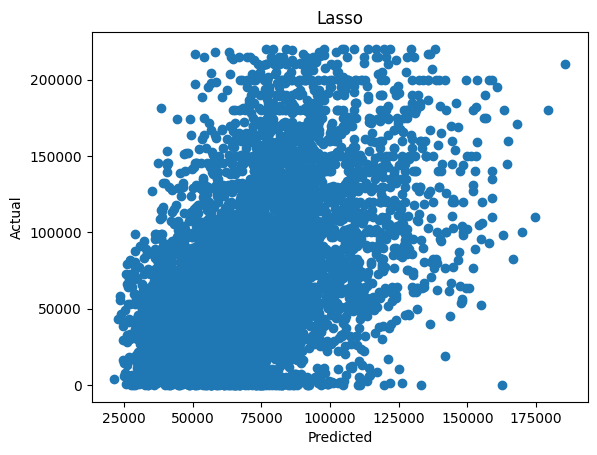

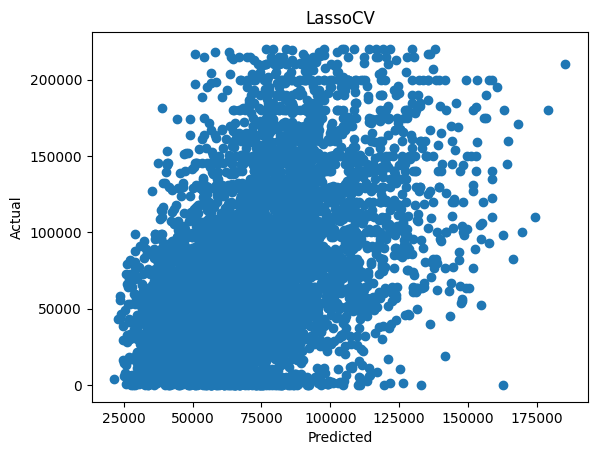

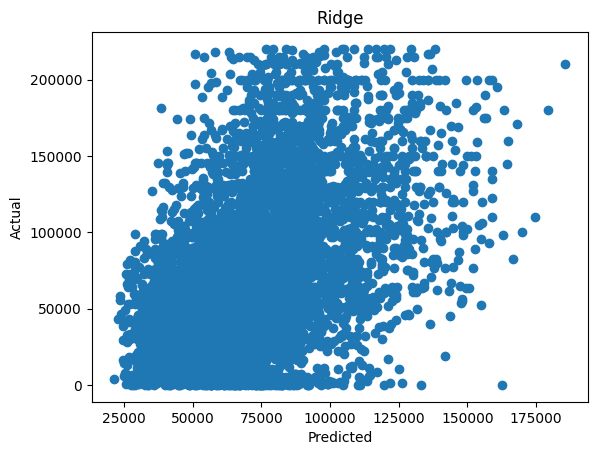

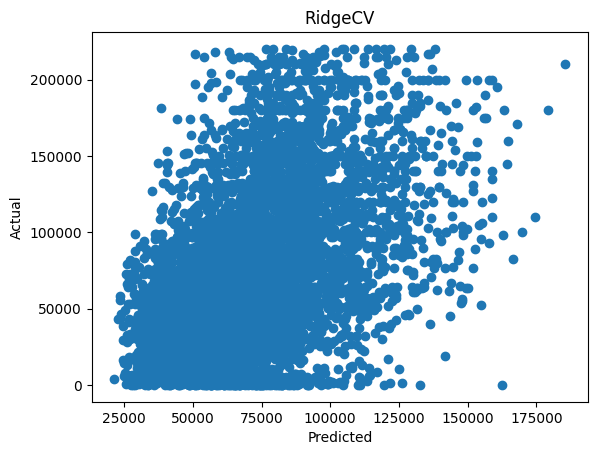

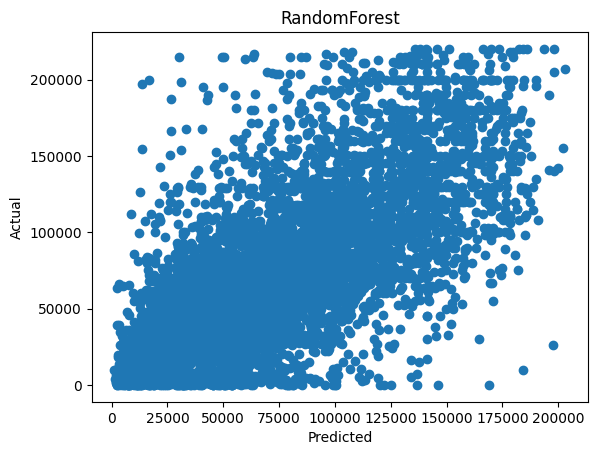

In [ ]:
from sklearn.linear_model import LinearRegression,LassoCV,RidgeCV,Ridge,Lasso,Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score 
models={
    "LinearRegression":LinearRegression(),
    "Lasso":Lasso(),
    "LassoCV":LassoCV(cv=10),
    "Ridge":Ridge(),
    "RidgeCV":RidgeCV(cv=10),
    "RandomForest":RandomForestRegressor(n_estimators=100)
}
results={}
for name,model in models.items():
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    plt.figure()
    plt.scatter(y_pred,y_test)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(name)
    score=r2_score(y_test,y_pred)
    print("R2_Score for :",name, "is",score)
    results[name]=score





In [52]:
final_model = RandomForestRegressor(random_state=42, max_depth=15)
final_model.fit(X, y)
data_to_save = {
    "model": final_model,
    "scaler": scaler,
    "le_country": le_country,
    "le_dev": le_dev
}
with open('saved_steps2.pkl', 'wb') as file:
    pickle.dump(data_to_save, file)

print("Smaller model saved!")

Smaller model saved!
